## Swin Transformer-Based Machine Learning Model for Multi-Class Skin Cancer Diagnosis

### STEP 1: Imports

In [1]:
# ======================
# Standard Library
# ======================
import gc
import os
import random
import time
import warnings
from pathlib import Path

# ======================
# Data Science
# ======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

# ======================
# Deep Learning
# ======================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm

# ======================
# ML Utilities
# ======================
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ======================
# Settings
# ======================
warnings.filterwarnings("ignore")

### STEP 2: Global Configuration

In [2]:
# from google.colab import drive
# drive.mount('/content/gdrive')A

In [3]:
try:
    import seaborn as sns
    sns.set_context("notebook")
    sns.set_style("whitegrid")
except Exception:
    pass

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)


NUM_WORKERS = 2 
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

MODEL_NAME = "swin_tiny_patch4_window7_224"
CHECKPOINT_PATH = "best_swin_ham10000.pth"

print(f"Using device: {DEVICE}")

Using device: mps


### STEP 3: Dataset Paths

In [4]:
if os.path.exists("/content"):
    DATA_ROOT = Path("/content/gdrive/MyDrive/Skin_Cancer")
else:
    DATA_ROOT = Path.home() / "Downloads" / "Skin_Cancer"

METADATA_PATH = DATA_ROOT / "HAM10000_metadata.csv"
IMAGE_DIRS = [
    DATA_ROOT / "HAM10000_images_part_1",
    DATA_ROOT / "HAM10000_images_part_2",
]
print("Dataset Path:", DATA_ROOT)

if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata file not found: {METADATA_PATH}")

for folder in IMAGE_DIRS:
    if not folder.exists():
        raise FileNotFoundError(f"Image folder not found: {folder}")

print("✅ Path is Okay.")

Dataset Path: /Users/abdurrahman/Downloads/Skin_Cancer
✅ Path is Okay.


### STEP 4: Load Metadata and Build Image Paths

In [5]:
df = pd.read_csv(METADATA_PATH)
print("Metadata shape:", df.shape)
display(df.head())

def find_image_path(image_id, image_dirs):
    for d in image_dirs:
        path = d / f"{image_id}.jpg"
        if path.exists():
            return str(path)
    return None

df["image_path"] = df["image_id"].apply(lambda x: find_image_path(x, IMAGE_DIRS))
df = df[df["image_path"].notna()].reset_index(drop=True)

print("Usable rows after path matching:", len(df))
print("Null image paths:", df["image_path"].isna().sum())

Metadata shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Usable rows after path matching: 10015
Null image paths: 0


### STEP 5: Basic Exploratory Data Analysis (EDA)

Class distribution:


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

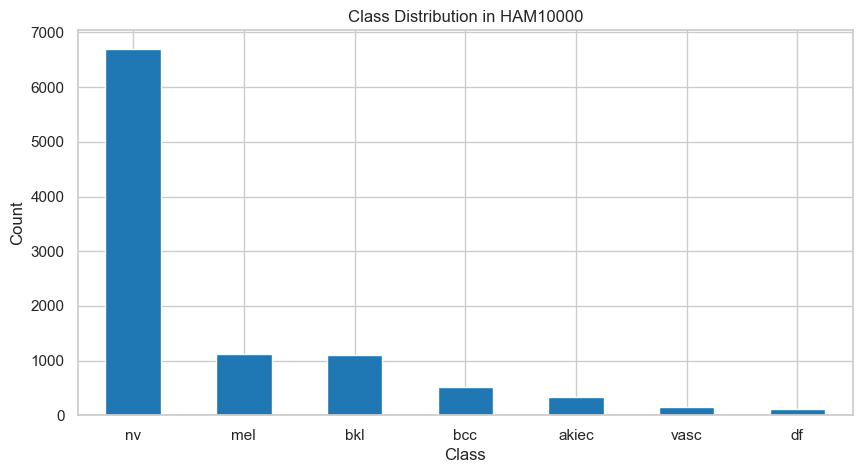


Missing values:


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
image_path       0
class_name       0
dtype: int64

In [6]:
CLASS_NAMES = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "vasc": "Vascular lesions",
}

df["class_name"] = df["dx"].map(CLASS_NAMES)

print("Class distribution:")
display(df["dx"].value_counts())

plt.figure(figsize=(10, 5))
df["dx"].value_counts().plot(kind="bar")
plt.title("Class Distribution in HAM10000")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print("\nMissing values:")
display(df.isnull().sum())

### STEP 6: Visualize Sample Images

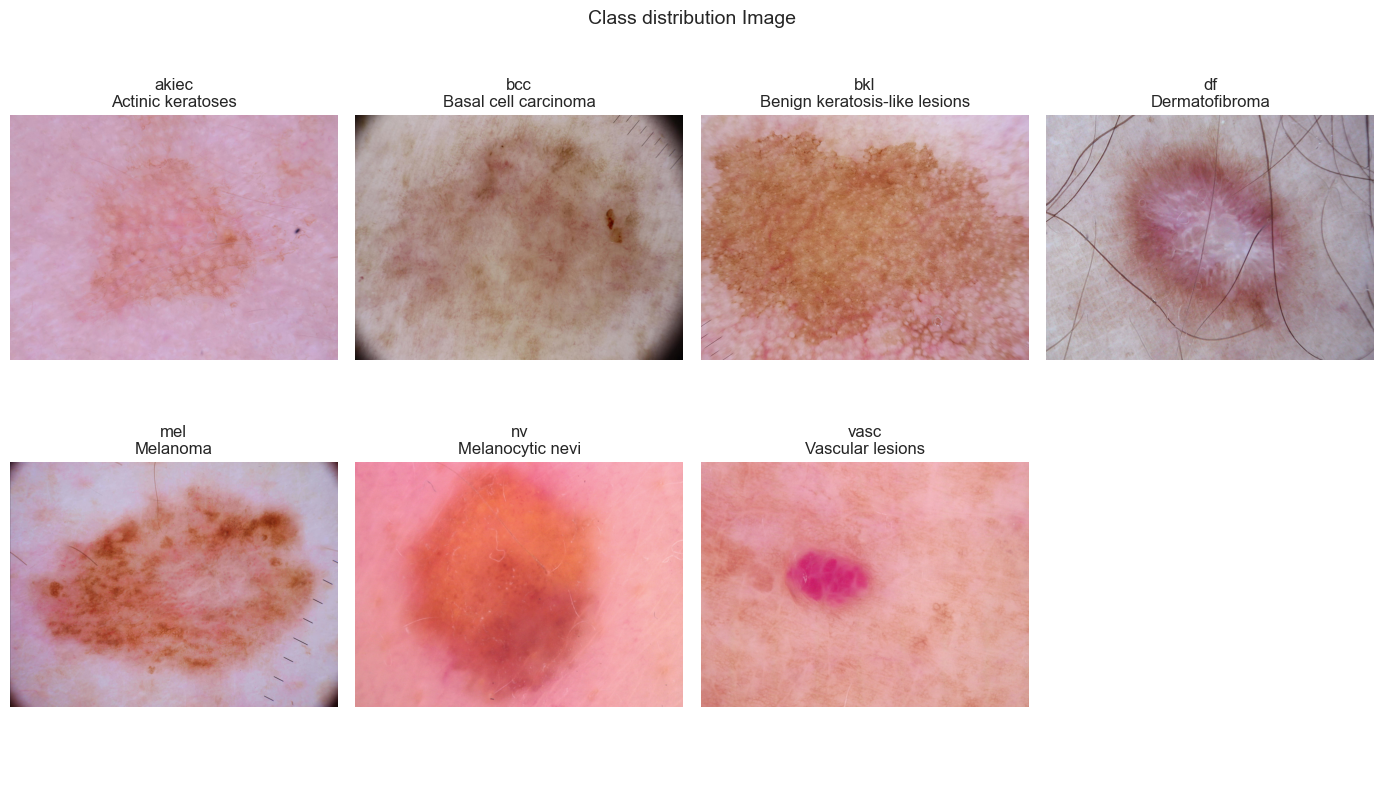

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

sample_df = df.groupby("dx", group_keys=False).apply(lambda x: x.sample(1, random_state=42))
sample_df = sample_df.reset_index(drop=True)

for idx, ax in enumerate(axes):
    if idx < len(sample_df):
        row = sample_df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f'{row["dx"]}\n{CLASS_NAMES[row["dx"]]}', fontsize=12)
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle("Class distribution Image", fontsize=14)
plt.tight_layout()
plt.show()

### STEP 7: Label Encoding and Train/Val/Test Split

In [8]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

label_to_class = {i: cls for i, cls in enumerate(le.classes_)}
class_to_label = {cls: i for i, cls in label_to_class.items()}

print("Encoded classes:", label_to_class)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42,
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain class distribution (before oversampling):")
display(train_df["dx"].value_counts())

Encoded classes: {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}
Train size: 7010
Validation size: 1502
Test size: 1503

Train class distribution (before oversampling):


dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

### STEP 8: Class Balancing with RandomOverSampler

Balanced training class distribution with counting:


dx
nv       4693
mel      4693
df       4693
bkl      4693
akiec    4693
vasc     4693
bcc      4693
Name: count, dtype: int64

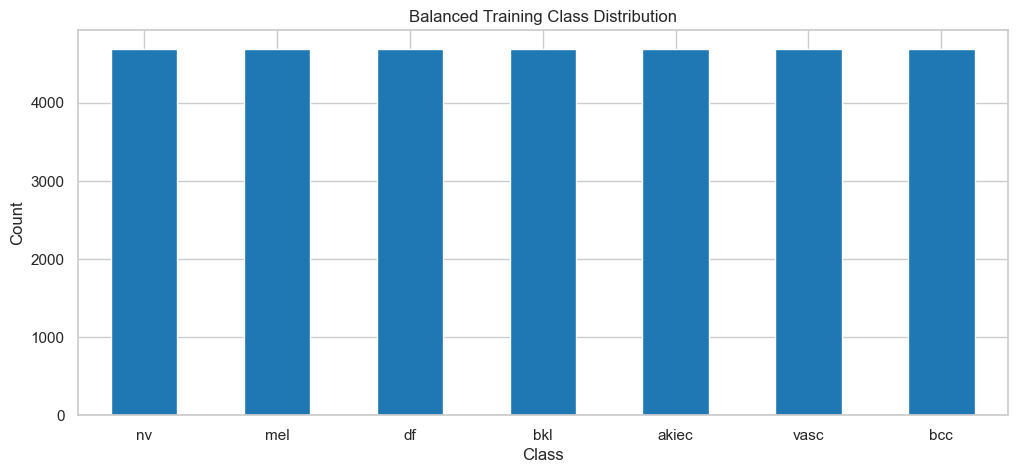

In [9]:
ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(
    train_df[["image_path"]],
    train_df["label"]
)

train_balanced_df = pd.DataFrame({
    "image_path": X_resampled["image_path"],
    "label": y_resampled
})

train_balanced_df["dx"] = train_balanced_df["label"].map(label_to_class)
train_balanced_df["class_name"] = train_balanced_df["dx"].map(CLASS_NAMES)

print("Balanced training class distribution with counting:")
display(train_balanced_df["dx"].value_counts())

plt.figure(figsize=(12, 5))
train_balanced_df["dx"].value_counts().plot(kind="bar")
plt.title("Balanced Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### STEP 9: Image Transforms

In [10]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


### STEP 10: Custom Dataset

In [11]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = HAM10000Dataset(train_balanced_df, transform=train_transforms)
val_dataset = HAM10000Dataset(val_df, transform=eval_transforms)
test_dataset = HAM10000Dataset(test_df, transform=eval_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 1027
Validation batches: 47
Test batches: 47


### STEP 11: Build the Swin Transformer Model

In [12]:
NUM_CLASSES = len(label_to_class)

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print(model.__class__.__name__)


SwinTransformer


### STEP 12: Training and Evaluation Utilities

In [13]:
from contextlib import nullcontext

def accuracy_from_logits(logits, labels):
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).float().mean().item()

def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    epoch_loss = 0.0
    epoch_acc = 0.0
    all_preds = []
    all_labels = []

    use_amp = torch.cuda.is_available()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    context = torch.enable_grad if is_train else torch.no_grad
    with context():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            amp_context = torch.cuda.amp.autocast if use_amp else nullcontext
            with amp_context():
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            acc = accuracy_from_logits(outputs, labels)

            epoch_loss += loss.item() * images.size(0)
            epoch_acc += acc * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss /= len(loader.dataset)
    epoch_acc /= len(loader.dataset)

    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

early_stopper = EarlyStopping(patience=4, min_delta=1e-4)


### STEP 13: Model Training

In [14]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_loss = float("inf")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss, train_acc, _, _ = run_one_epoch(
        model, train_loader, criterion, optimizer=optimizer
    )
    val_loss, val_acc, _, _ = run_one_epoch(
        model, val_loader, criterion, optimizer=None
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Best model saved to {CHECKPOINT_PATH}")

    early_stopper(val_loss)
    if early_stopper.should_stop:
        print("⏹ Early stopping triggered.")
        break

    print("-" * 60)

elapsed = time.time() - start_time
print(f"Training completed in {elapsed / 60:.2f} minutes.")


Epoch [1/10]


  0%|          | 0/1027 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.4275 | Train Acc: 0.8406
Val   Loss: 0.5023 | Val   Acc: 0.7963
✅ Best model saved to best_swin_ham10000.pth
------------------------------------------------------------
Epoch [2/10]


  0%|          | 0/1027 [00:00<?, ?it/s]

...

  0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.0483 | Train Acc: 0.9836
Val   Loss: 0.4819 | Val   Acc: 0.8835
------------------------------------------------------------
Epoch [10/10]


  0%|          | 0/1027 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.0457 | Train Acc: 0.9846
Val   Loss: 0.4808 | Val   Acc: 0.8822
------------------------------------------------------------
Training completed in 156.22 minutes.


### STEP 14: Training Curves

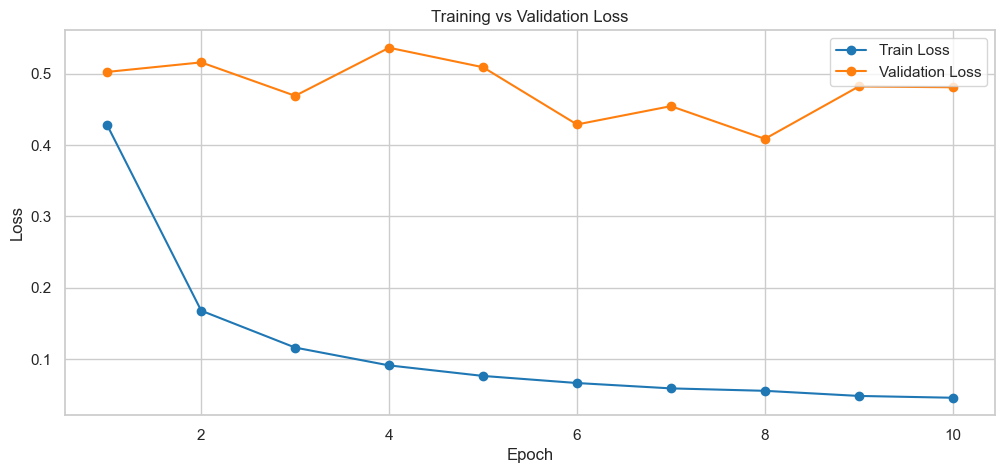

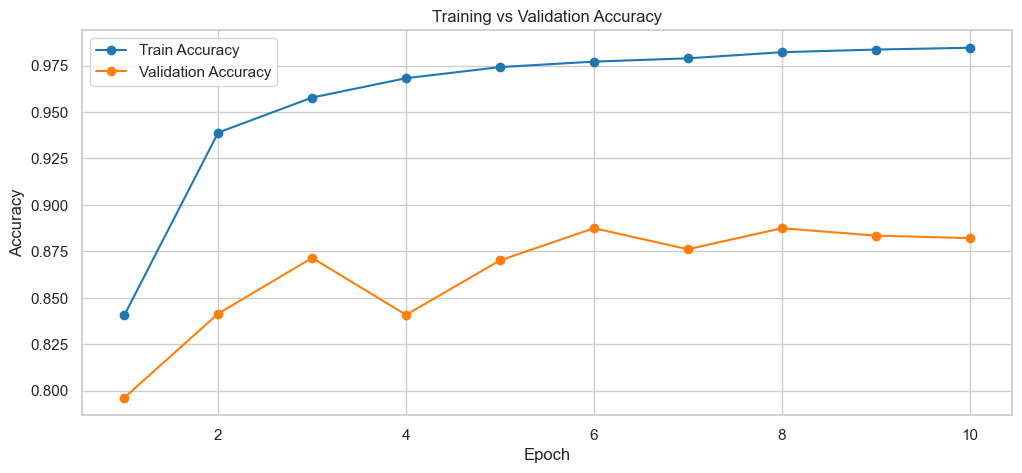

In [15]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### STEP 15: Test Set Evaluation

In [16]:
best_model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES
).to(DEVICE)

best_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
best_model.eval()

test_loss, test_acc, test_preds, test_labels = run_one_epoch(
    best_model, test_loader, criterion, optimizer=None
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

  0%|          | 0/47 [00:00<?, ?it/s]

Test Loss: 0.4230
Test Accuracy: 0.8876


### STEP16: Detailed Metrics

Classification Report:
                               precision    recall  f1-score   support

            Actinic keratoses     0.7708    0.7551    0.7629        49
         Basal cell carcinoma     0.7216    0.9091    0.8046        77
Benign keratosis-like lesions     0.8231    0.7333    0.7756       165
               Dermatofibroma     0.9167    0.6471    0.7586        17
                     Melanoma     0.7439    0.7305    0.7372       167
             Melanocytic nevi     0.9435    0.9463    0.9449      1006
             Vascular lesions     0.8077    0.9545    0.8750        22

                     accuracy                         0.8876      1503
                    macro avg     0.8182    0.8109    0.8084      1503
                 weighted avg     0.8888    0.8876    0.8870      1503



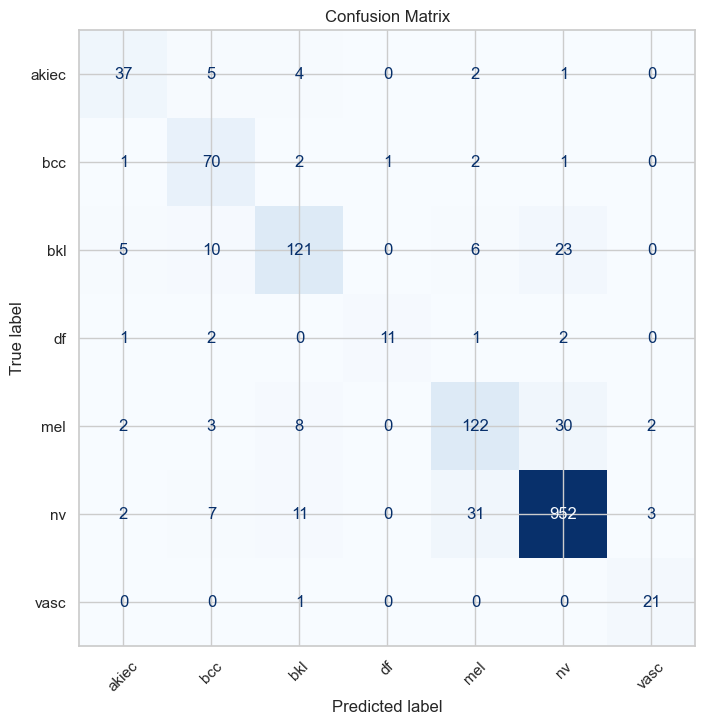

In [17]:
target_names = [CLASS_NAMES[c] for c in le.classes_]

print("Classification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=target_names,
    digits=4
))

cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

### STEP 17: Single Image Inference Utility

In [18]:
def predict_image(image_path, model, transform, label_encoder):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
        pred_class = label_encoder.inverse_transform([pred_idx])[0]

    return {
        "predicted_label_index": pred_idx,
        "predicted_class_code": pred_class,
        "predicted_class_name": CLASS_NAMES[pred_class],
        "confidence": float(probs[pred_idx]),
        "all_probabilities": {
            label_encoder.inverse_transform([i])[0]: float(probs[i])
            for i in range(len(probs))
        }
    }

### STEP 18: Visual Demo on a Test Image

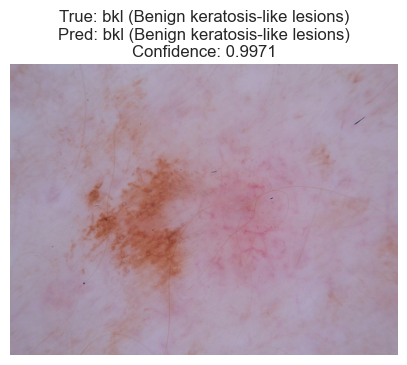

In [19]:
idx = 0
demo_path = test_df.iloc[idx]["image_path"]
demo_true = test_df.iloc[idx]["dx"]

result = predict_image(demo_path, best_model, eval_transforms, le)

img = Image.open(demo_path).convert("RGB")
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"True: {demo_true} ({CLASS_NAMES[demo_true]})\n"
    f"Pred: {result['predicted_class_code']} ({result['predicted_class_name']})\n"
    f"Confidence: {result['confidence']:.4f}"
)
plt.show()


### STEP 19. Save Project Artifacts

In [20]:
artifacts = {
    "class_to_label": class_to_label,
    "label_to_class": label_to_class,
    "class_name_mapping": CLASS_NAMES,
    "history": history,
    "model_name": MODEL_NAME,
    "img_size": IMG_SIZE,
    "checkpoint_path": CHECKPOINT_PATH
}

import json
with open("project_artifacts.json", "w") as f:
    json.dump(artifacts, f, indent=4)

print("Saved:")
print("- Model checkpoint:", CHECKPOINT_PATH)
print("- Project metadata: project_artifacts.json")


Saved:
- Model checkpoint: best_swin_ham10000.pth
- Project metadata: project_artifacts.json
